# Retail Demand Forecasting — Day 4: Prophet + LightGBM
## Classical vs ML Benchmark

**Objective:** Add Prophet and LightGBM to the benchmark. Produce a final 4-model comparison table.

**Resuming from:** `outputs/day3_final_results.csv` — Day 3 best results per department

**Models this notebook:**
- Facebook Prophet — decomposition-based, handles seasonality and holidays natively
- LightGBM — gradient boosted trees with lag/rolling feature engineering

**Key questions to answer:**
1. Does Prophet's multiplicative seasonality fix Dept 72's holiday spike problem?
2. Do LightGBM lag features finally explain Dept 95's unexplained variance?
3. Does LightGBM overcome Dept 38's structural break?
4. Which model wins per department across all 4 days?

**Final benchmark target (Day 3 best):**

| Dept | Best RMSE | Best MAPE | Model |
|---|---|---|---|
| 2  | 6,160  | 2.30% | SARIMA refit |
| 38 | 23,032 | 7.08% | SARIMA |
| 72 | 24,881 | 10.07% | ARIMAX |
| 92 | 14,002 | 3.63% | SARIMA |
| 95 | 14,679 | 3.86% | ARIMAX |

---
## 0. Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import os

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from prophet import Prophet
print('Prophet installed successfully')

os.makedirs('outputs', exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

HOLDOUT = 30
print(f'LightGBM version: {lgb.__version__}')
print(f'Holdout: {HOLDOUT} weeks')

Prophet installed successfully
LightGBM version: 4.6.0
Holdout: 30 weeks


---
## 1. Load Data + Previous Best Results

In [3]:
df = pd.read_csv('outputs/walmart_processed.csv', parse_dates=['date'])
df = df.drop(columns=['cpi', 'unemployment', 'type', 'size'])

STORES = df['store'].unique().tolist()
DEPTS  = df['dept'].unique().tolist()

# ── Load Day 3 best results as benchmark ─────────────────────
day3_df = pd.read_csv('outputs/day3_final_results.csv')
day3_df['dept'] = day3_df['dept'].astype(int)

# Build benchmark dict
BENCHMARK = {}
for _, row in day3_df.iterrows():
    BENCHMARK[int(row['dept'])] = {
        'rmse'  : row['arimax_rmse'],
        'mape'  : row['arimax_mape'],
        'model' : row['winner']
    }

print('=== Benchmark to Beat (Day 3 Best) ===')
for dept, v in BENCHMARK.items():
    print(f'  Dept {dept}: RMSE={v["rmse"]:>10,.2f} | MAPE={v["mape"]:.2f}% | Model={v["model"]}')
print()
print(f'Data shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

=== Benchmark to Beat (Day 3 Best) ===
  Dept 2: RMSE=  6,160.45 | MAPE=2.30% | Model=SARIMA refit
  Dept 38: RMSE= 23,031.93 | MAPE=7.08% | Model=SARIMA
  Dept 72: RMSE= 24,880.86 | MAPE=10.07% | Model=ARIMAX
  Dept 92: RMSE= 14,001.91 | MAPE=3.63% | Model=SARIMA
  Dept 95: RMSE= 14,679.49 | MAPE=3.86% | Model=ARIMAX

Data shape: (2141, 8)
Columns: ['store', 'dept', 'date', 'weekly_sales', 'isholiday', 'temperature', 'fuel_price', 'total_markdown']


---
## 2. Helper Functions

In [4]:
def compute_metrics(actual, predicted, model_name=''):
    actual    = np.array(actual)
    predicted = np.array(predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100
    if model_name:
        benchmark_rmse = None
        print(f'  {model_name:40s} | RMSE={rmse:>10.2f} | MAPE={mape:>6.2f}%')
    return {'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'MAPE': round(mape, 2)}


def build_series(dept):
    """Simple weekly sales series for Prophet and SARIMA."""
    return (
        df[df['dept'] == dept]
        .groupby('date')['weekly_sales']
        .sum()
        .asfreq('W-FRI')
        .ffill()
    )


def build_features_df(dept):
    """Full feature dataframe for LightGBM."""
    d = df[df['dept'] == dept].groupby('date').agg(
        weekly_sales   = ('weekly_sales',   'sum'),
        temperature    = ('temperature',    'mean'),
        fuel_price     = ('fuel_price',     'mean'),
        isholiday      = ('isholiday',      'max'),
        total_markdown = ('total_markdown', 'sum')
    ).asfreq('W-FRI').ffill()
    d['isholiday'] = d['isholiday'].astype(int)
    return d


def split_series(series, holdout=HOLDOUT):
    return series.iloc[:-holdout], series.iloc[-holdout:]


def split_df(data, holdout=HOLDOUT):
    return data.iloc[:-holdout], data.iloc[-holdout:]


print('Helper functions defined.')

Helper functions defined.


---
## 3. Prophet — Decomposition-Based Forecasting

> Prophet decomposes the series into trend + seasonality + holidays.
> Key advantage over SARIMA: handles multiple seasonalities and holiday effects natively.
>
> **Day 4 hypothesis for Dept 72:**
> The large holiday spike (1M in Dec 2011) may be better captured by
> Prophet's multiplicative seasonality mode than SARIMA's additive seasonal terms.
> Multiplicative: seasonal effect scales with trend level.
> Additive: seasonal effect is constant absolute size.
>
> **Testing both modes per department — select by holdout RMSE.**

In [6]:
prophet_results = {}

print('Fitting Prophet (additive + multiplicative) per department...')
print('-' * 65)

for dept in DEPTS:
    series      = build_series(dept)
    train, test = split_series(series)

    # Prepare Prophet format — requires ds and y columns
    train_df = train.reset_index()
    train_df.columns = ['ds', 'y']
    test_df  = test.reset_index()
    test_df.columns  = ['ds', 'y']

    best_rmse  = np.inf
    best_mode  = None
    best_preds = None

    for mode in ['additive', 'multiplicative']:
        try:
            m = Prophet(
                yearly_seasonality  = True,
                weekly_seasonality  = False,   # weekly data — no within-week pattern
                daily_seasonality   = False,
                seasonality_mode    = mode,
                interval_width      = 0.95
            )
            # Add US holidays — Walmart is a US retailer
            m.add_country_holidays(country_name='US')
            m.fit(train_df)

            future = m.make_future_dataframe(periods=HOLDOUT, freq='W')
            forecast = m.predict(future)
            preds = forecast['yhat'].iloc[-HOLDOUT:].values
            preds = np.maximum(preds, 0)

            metrics = compute_metrics(test_df['y'].values, preds,
                                        model_name=f'Dept {dept} Prophet({mode})')
            if metrics['RMSE'] < best_rmse:
                best_rmse  = metrics['RMSE']
                best_mode  = mode
                best_preds = preds
                best_metrics = metrics

        except Exception as e:
            print(f'  Dept {dept} Prophet({mode}) failed: {e}')

    prophet_results[dept] = {
        **best_metrics,
        'mode'       : best_mode,
        'predictions': best_preds
    }

    bench = BENCHMARK[dept]['rmse']
    improvement = (bench - best_rmse) / bench * 100
    print(f'  Best mode: {best_mode} | vs benchmark: {improvement:+.1f}%')
    print()

print('Prophet fitting complete.')

Fitting Prophet (additive + multiplicative) per department...
-----------------------------------------------------------------


08:01:05 - cmdstanpy - INFO - Chain [1] start processing
08:01:07 - cmdstanpy - INFO - Chain [1] done processing


  Dept 2 Prophet(additive)                 | RMSE=  10154.36 | MAPE=  4.30%


08:01:07 - cmdstanpy - INFO - Chain [1] start processing
08:01:07 - cmdstanpy - INFO - Chain [1] done processing


  Dept 2 Prophet(multiplicative)           | RMSE=  10115.76 | MAPE=  4.29%
  Best mode: multiplicative | vs benchmark: -64.2%



...

  Dept 92 Prophet(multiplicative)          | RMSE=  23025.75 | MAPE=  6.35%
  Best mode: additive | vs benchmark: -64.3%



08:01:11 - cmdstanpy - INFO - Chain [1] start processing
08:01:11 - cmdstanpy - INFO - Chain [1] done processing


  Dept 95 Prophet(additive)                | RMSE=  17312.67 | MAPE=  4.94%


08:01:12 - cmdstanpy - INFO - Chain [1] start processing
08:01:12 - cmdstanpy - INFO - Chain [1] done processing


  Dept 95 Prophet(multiplicative)          | RMSE=  17180.26 | MAPE=  4.89%
  Best mode: multiplicative | vs benchmark: -17.0%

Prophet fitting complete.


---
## 4. LightGBM — Feature Engineering

> LightGBM requires manual feature engineering for time series.
> The model has no concept of time — it learns from tabular features.
>
> **Feature types:**
> - **Lag features**: sales from 1, 4, 8, 12, 26, 52 weeks ago
> - **Rolling features**: rolling mean and std over 4, 8, 26 weeks
> - **Calendar features**: week of year, month, quarter, is_weekend
> - **Exogenous features**: temperature, fuel_price, isholiday, total_markdown
>
> **Critical: use TimeSeriesSplit not random split**
> Random splitting leaks future data into training — not valid for time series.

In [7]:
def build_lgbm_features(dept):
    """
    Build lag + rolling + calendar + exogenous features for LightGBM.
    All lag/rolling features shifted by 1 minimum to prevent data leakage.
    """
    d = build_features_df(dept).copy()

    # ── Lag features ──────────────────────────────────────────
    for lag in [1, 4, 8, 12, 26, 52]:
        d[f'lag_{lag}'] = d['weekly_sales'].shift(lag)

    # ── Rolling features (shift 1 first to prevent leakage) ──
    for window in [4, 8, 26]:
        shifted = d['weekly_sales'].shift(1)
        d[f'rolling_mean_{window}'] = shifted.rolling(window).mean()
        d[f'rolling_std_{window}']  = shifted.rolling(window).std()

    # ── Calendar features ─────────────────────────────────────
    d['week_of_year'] = d.index.isocalendar().week.astype(int)
    d['month']        = d.index.month
    d['quarter']      = d.index.quarter
    d['year']         = d.index.year

    # ── Lag fuel price (1 week) ───────────────────────────────
    d['fuel_price_lag1'] = d['fuel_price'].shift(1)
    d = d.drop(columns=['fuel_price'])

    # Drop NaN rows from lag/rolling creation
    d = d.dropna()

    return d


# Feature columns — everything except target
FEATURE_COLS = None  # set after first build to ensure consistency

# Test build on one dept
sample = build_lgbm_features(DEPTS[0])
FEATURE_COLS = [c for c in sample.columns if c != 'weekly_sales']

print(f'Feature count: {len(FEATURE_COLS)}')
print(f'Features: {FEATURE_COLS}')
print(f'Sample shape after lag/rolling: {sample.shape}')
print(f'Observations lost to lag creation: {build_features_df(DEPTS[0]).shape[0] - sample.shape[0]}')

Feature count: 20
Features: ['temperature', 'isholiday', 'total_markdown', 'lag_1', 'lag_4', 'lag_8', 'lag_12', 'lag_26', 'lag_52', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'rolling_std_8', 'rolling_mean_26', 'rolling_std_26', 'week_of_year', 'month', 'quarter', 'year', 'fuel_price_lag1']
Sample shape after lag/rolling: (91, 21)
Observations lost to lag creation: 52


---
## 5. LightGBM — Model Fitting

> **Key design decisions:**
> 1. TimeSeriesSplit for validation — no random split
> 2. Early stopping on validation set — prevents overfitting
> 3. Per-department model — separate model per dept, not one global model
> 4. Feature importance logged — interpretability story

In [8]:
lgbm_results  = {}
lgbm_models   = {}
feature_importance_dfs = {}

lgbm_params = {
    'objective'       : 'regression',
    'metric'          : 'rmse',
    'learning_rate'   : 0.05,
    'num_leaves'      : 16,       # conservative — small dataset
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq'    : 5,
    'min_child_samples': 5,
    'verbose'         : -1
}

print('Fitting LightGBM per department...')
print('Using TimeSeriesSplit(n_splits=3) for validation')
print('-' * 65)

for dept in DEPTS:
    data        = build_lgbm_features(dept)
    train, test = split_df(data)

    X_train = train[FEATURE_COLS]
    y_train = train['weekly_sales']
    X_test  = test[FEATURE_COLS]
    y_test  = test['weekly_sales']

    # TimeSeriesSplit — respects temporal ordering
    tscv = TimeSeriesSplit(n_splits=3)

    # Use last fold as validation for early stopping
    val_idx = list(tscv.split(X_train))[-1]
    X_tr  = X_train.iloc[val_idx[0]]
    y_tr  = y_train.iloc[val_idx[0]]
    X_val = X_train.iloc[val_idx[1]]
    y_val = y_train.iloc[val_idx[1]]

    dtrain = lgb.Dataset(X_tr,  label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    model = lgb.train(
        lgbm_params,
        dtrain,
        num_boost_round   = 500,
        valid_sets        = [dval],
        callbacks         = [lgb.early_stopping(50, verbose=False),
                             lgb.log_evaluation(period=-1)]
    )

    preds   = np.maximum(model.predict(X_test), 0)
    metrics = compute_metrics(y_test, preds,
                              model_name=f'Dept {dept} LightGBM')

    bench       = BENCHMARK[dept]['rmse']
    improvement = (bench - metrics['RMSE']) / bench * 100

    lgbm_results[dept] = {
        **metrics,
        'n_estimators': model.best_iteration,
        'improvement_%': round(improvement, 1),
        'predictions'  : preds
    }
    lgbm_models[dept] = model

    # Feature importance
    fi = pd.DataFrame({
        'feature'   : FEATURE_COLS,
        'importance': model.feature_importance(importance_type='gain')
    }).sort_values('importance', ascending=False)
    feature_importance_dfs[dept] = fi

    print(f'  Best iteration: {model.best_iteration} | vs benchmark: {improvement:+.1f}%')
    print()

print('LightGBM fitting complete.')

Fitting LightGBM per department...
Using TimeSeriesSplit(n_splits=3) for validation
-----------------------------------------------------------------
  Dept 2 LightGBM                          | RMSE=   6544.75 | MAPE=  2.11%
  Best iteration: 90 | vs benchmark: -6.2%

  Dept 38 LightGBM                         | RMSE=  20684.43 | MAPE=  6.36%
  Best iteration: 155 | vs benchmark: +10.2%

  Dept 72 LightGBM                         | RMSE=  29019.08 | MAPE= 13.50%
  Best iteration: 47 | vs benchmark: -16.6%

  Dept 92 LightGBM                         | RMSE=  15843.81 | MAPE=  4.21%
  Best iteration: 93 | vs benchmark: -13.2%

  Dept 95 LightGBM                         | RMSE=  18249.37 | MAPE=  4.85%
  Best iteration: 33 | vs benchmark: -24.3%

LightGBM fitting complete.


---
## 6. LightGBM Feature Importance

> Feature importance reveals what the model actually learned.
> Expected: lag_52 and rolling_mean_26 should dominate — annual seasonality.
> If lag_1 dominates — the model is primarily doing one-step-ahead smoothing.
> If calendar features dominate — the model learned seasonal patterns via week_of_year.

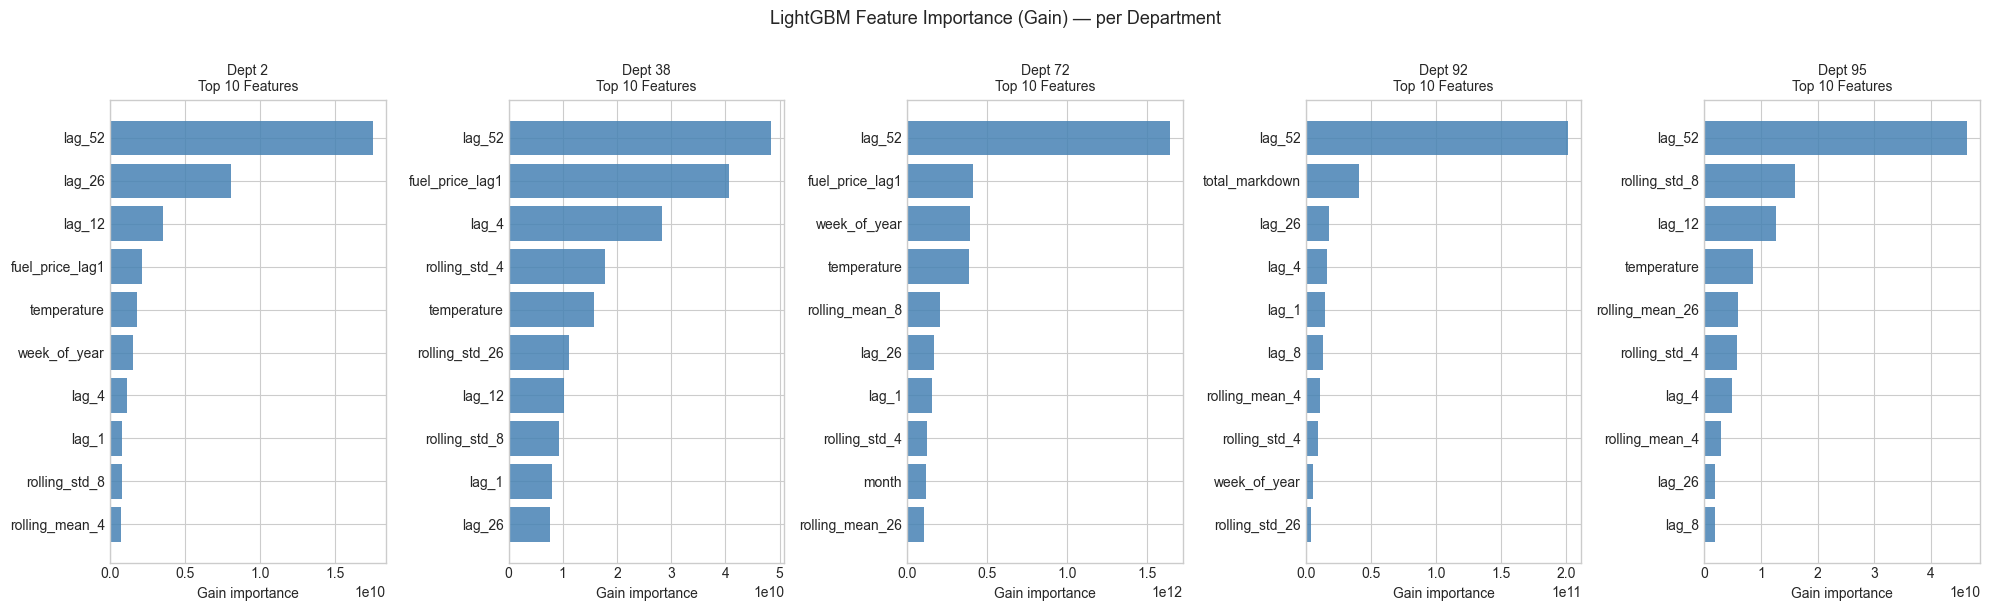

Saved → outputs/15_lgbm_feature_importance.png

Top 3 features per department:
--------------------------------------------------
  Dept 2: ['lag_52', 'lag_26', 'lag_12']
  Dept 38: ['lag_52', 'fuel_price_lag1', 'lag_4']
  Dept 72: ['lag_52', 'fuel_price_lag1', 'week_of_year']
  Dept 92: ['lag_52', 'total_markdown', 'lag_26']
  Dept 95: ['lag_52', 'rolling_std_8', 'lag_12']


In [9]:
fig, axes = plt.subplots(1, len(DEPTS), figsize=(4*len(DEPTS), 6))

for i, dept in enumerate(DEPTS):
    fi = feature_importance_dfs[dept].head(10)

    axes[i].barh(fi['feature'], fi['importance'],
                 color='steelblue', alpha=0.85)
    axes[i].set_title(f'Dept {dept}\nTop 10 Features', fontsize=10)
    axes[i].set_xlabel('Gain importance')
    axes[i].invert_yaxis()

plt.suptitle('LightGBM Feature Importance (Gain) — per Department',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/15_lgbm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/15_lgbm_feature_importance.png')
print()
print('Top 3 features per department:')
print('-' * 50)
for dept in DEPTS:
    top3 = feature_importance_dfs[dept].head(3)['feature'].tolist()
    print(f'  Dept {dept}: {top3}')

---
## 7. Final 4-Model Benchmark Table

> The complete comparison: ARIMA → SARIMA → ARIMAX → Prophet → LightGBM
> Winner per department selected by lowest holdout RMSE.

In [10]:
# Load all previous results
arima_df  = pd.read_csv('outputs/day2_baseline_results.csv')
day3_df   = pd.read_csv('outputs/day3_final_results.csv')

arima_df['dept']  = arima_df['Dept'].astype(int)
day3_df['dept']   = day3_df['dept'].astype(int)

rows = []
for dept in DEPTS:
    # Day 2 results
    a2 = arima_df[arima_df['dept']==dept].iloc[0]
    arima_rmse  = float(a2['ARIMA RMSE'])
    sarima_rmse = float(a2['SARIMA RMSE'])

    # Day 3 results
    d3 = day3_df[day3_df['dept']==dept].iloc[0]
    arimax_rmse = float(d3['arimax_rmse'])
    arimax_mape = float(d3['arimax_mape'])

    # Day 4 results
    prophet_rmse = prophet_results[dept]['RMSE'] if prophet_results[dept]['RMSE'] != np.inf else None
    prophet_mape = prophet_results[dept]['MAPE'] if prophet_results[dept]['RMSE'] != np.inf else None
    prophet_mode = prophet_results[dept].get('mode', 'N/A')

    lgbm_rmse = lgbm_results[dept]['RMSE']
    lgbm_mape = lgbm_results[dept]['MAPE']

    # Find overall winner
    candidates = {
        'SARIMA' : sarima_rmse,
        'ARIMAX' : arimax_rmse,
        'LightGBM': lgbm_rmse,
    }
    if prophet_rmse:
        candidates['Prophet'] = prophet_rmse

    overall_winner = min(candidates, key=candidates.get)
    best_rmse      = candidates[overall_winner]
    bench_rmse     = BENCHMARK[dept]['rmse']
    overall_improvement = (bench_rmse - best_rmse) / bench_rmse * 100

    rows.append({
        'Dept'             : dept,
        'ARIMA RMSE'       : arima_rmse,
        'SARIMA RMSE'      : sarima_rmse,
        'ARIMAX RMSE'      : arimax_rmse,
        'Prophet RMSE'     : prophet_rmse if prophet_rmse else 'N/A',
        'Prophet mode'     : prophet_mode,
        'LightGBM RMSE'    : lgbm_rmse,
        'Overall Winner'   : overall_winner,
        'Best RMSE'        : best_rmse,
        'vs ARIMA %'       : round((arima_rmse - best_rmse)/arima_rmse*100, 1),
    })

benchmark_df = pd.DataFrame(rows)

print('=' * 100)
print('FINAL 4-MODEL BENCHMARK — All Days')
print('=' * 100)
print(benchmark_df[[
    'Dept','ARIMA RMSE','SARIMA RMSE','ARIMAX RMSE',
    'Prophet RMSE','LightGBM RMSE','Overall Winner','Best RMSE','vs ARIMA %'
]].to_string(index=False))
print()
print('Winners:')
for _, row in benchmark_df.iterrows():
    print(f"  Dept {row['Dept']:>2}: {row['Overall Winner']:10s} "
          f"RMSE={row['Best RMSE']:>10,.2f} | "
          f"{row['vs ARIMA %']:>+.1f}% vs ARIMA baseline")

benchmark_df.to_csv('outputs/day4_final_benchmark.csv', index=False)
print('\nSaved → outputs/day4_final_benchmark.csv')

FINAL 4-MODEL BENCHMARK — All Days
 Dept  ARIMA RMSE  SARIMA RMSE  ARIMAX RMSE  Prophet RMSE  LightGBM RMSE Overall Winner  Best RMSE  vs ARIMA %
    2    10142.90      7170.35      6160.45      10115.76        6544.75         ARIMAX    6160.45       39.30
   38    26645.11     23031.93     23031.93      17784.92       20684.43        Prophet   17784.92       33.30
   72    71601.94     27768.65     24880.86      31500.43       29019.08         ARIMAX   24880.86       65.30
   92    24267.77     14001.91     14001.91      23010.29       15843.81         SARIMA   14001.91       42.30
   95    15189.77     15189.77     14679.49      17180.26       18249.37         ARIMAX   14679.49        3.40

Winners:
  Dept  2: ARIMAX     RMSE=  6,160.45 | +39.3% vs ARIMA baseline
  Dept 38: Prophet    RMSE= 17,784.92 | +33.3% vs ARIMA baseline
  Dept 72: ARIMAX     RMSE= 24,880.86 | +65.3% vs ARIMA baseline
  Dept 92: SARIMA     RMSE= 14,001.91 | +42.3% vs ARIMA baseline
  Dept 95: ARIMAX     RMSE= 1

---
## 8. Forecast Plots — All Models vs Actuals

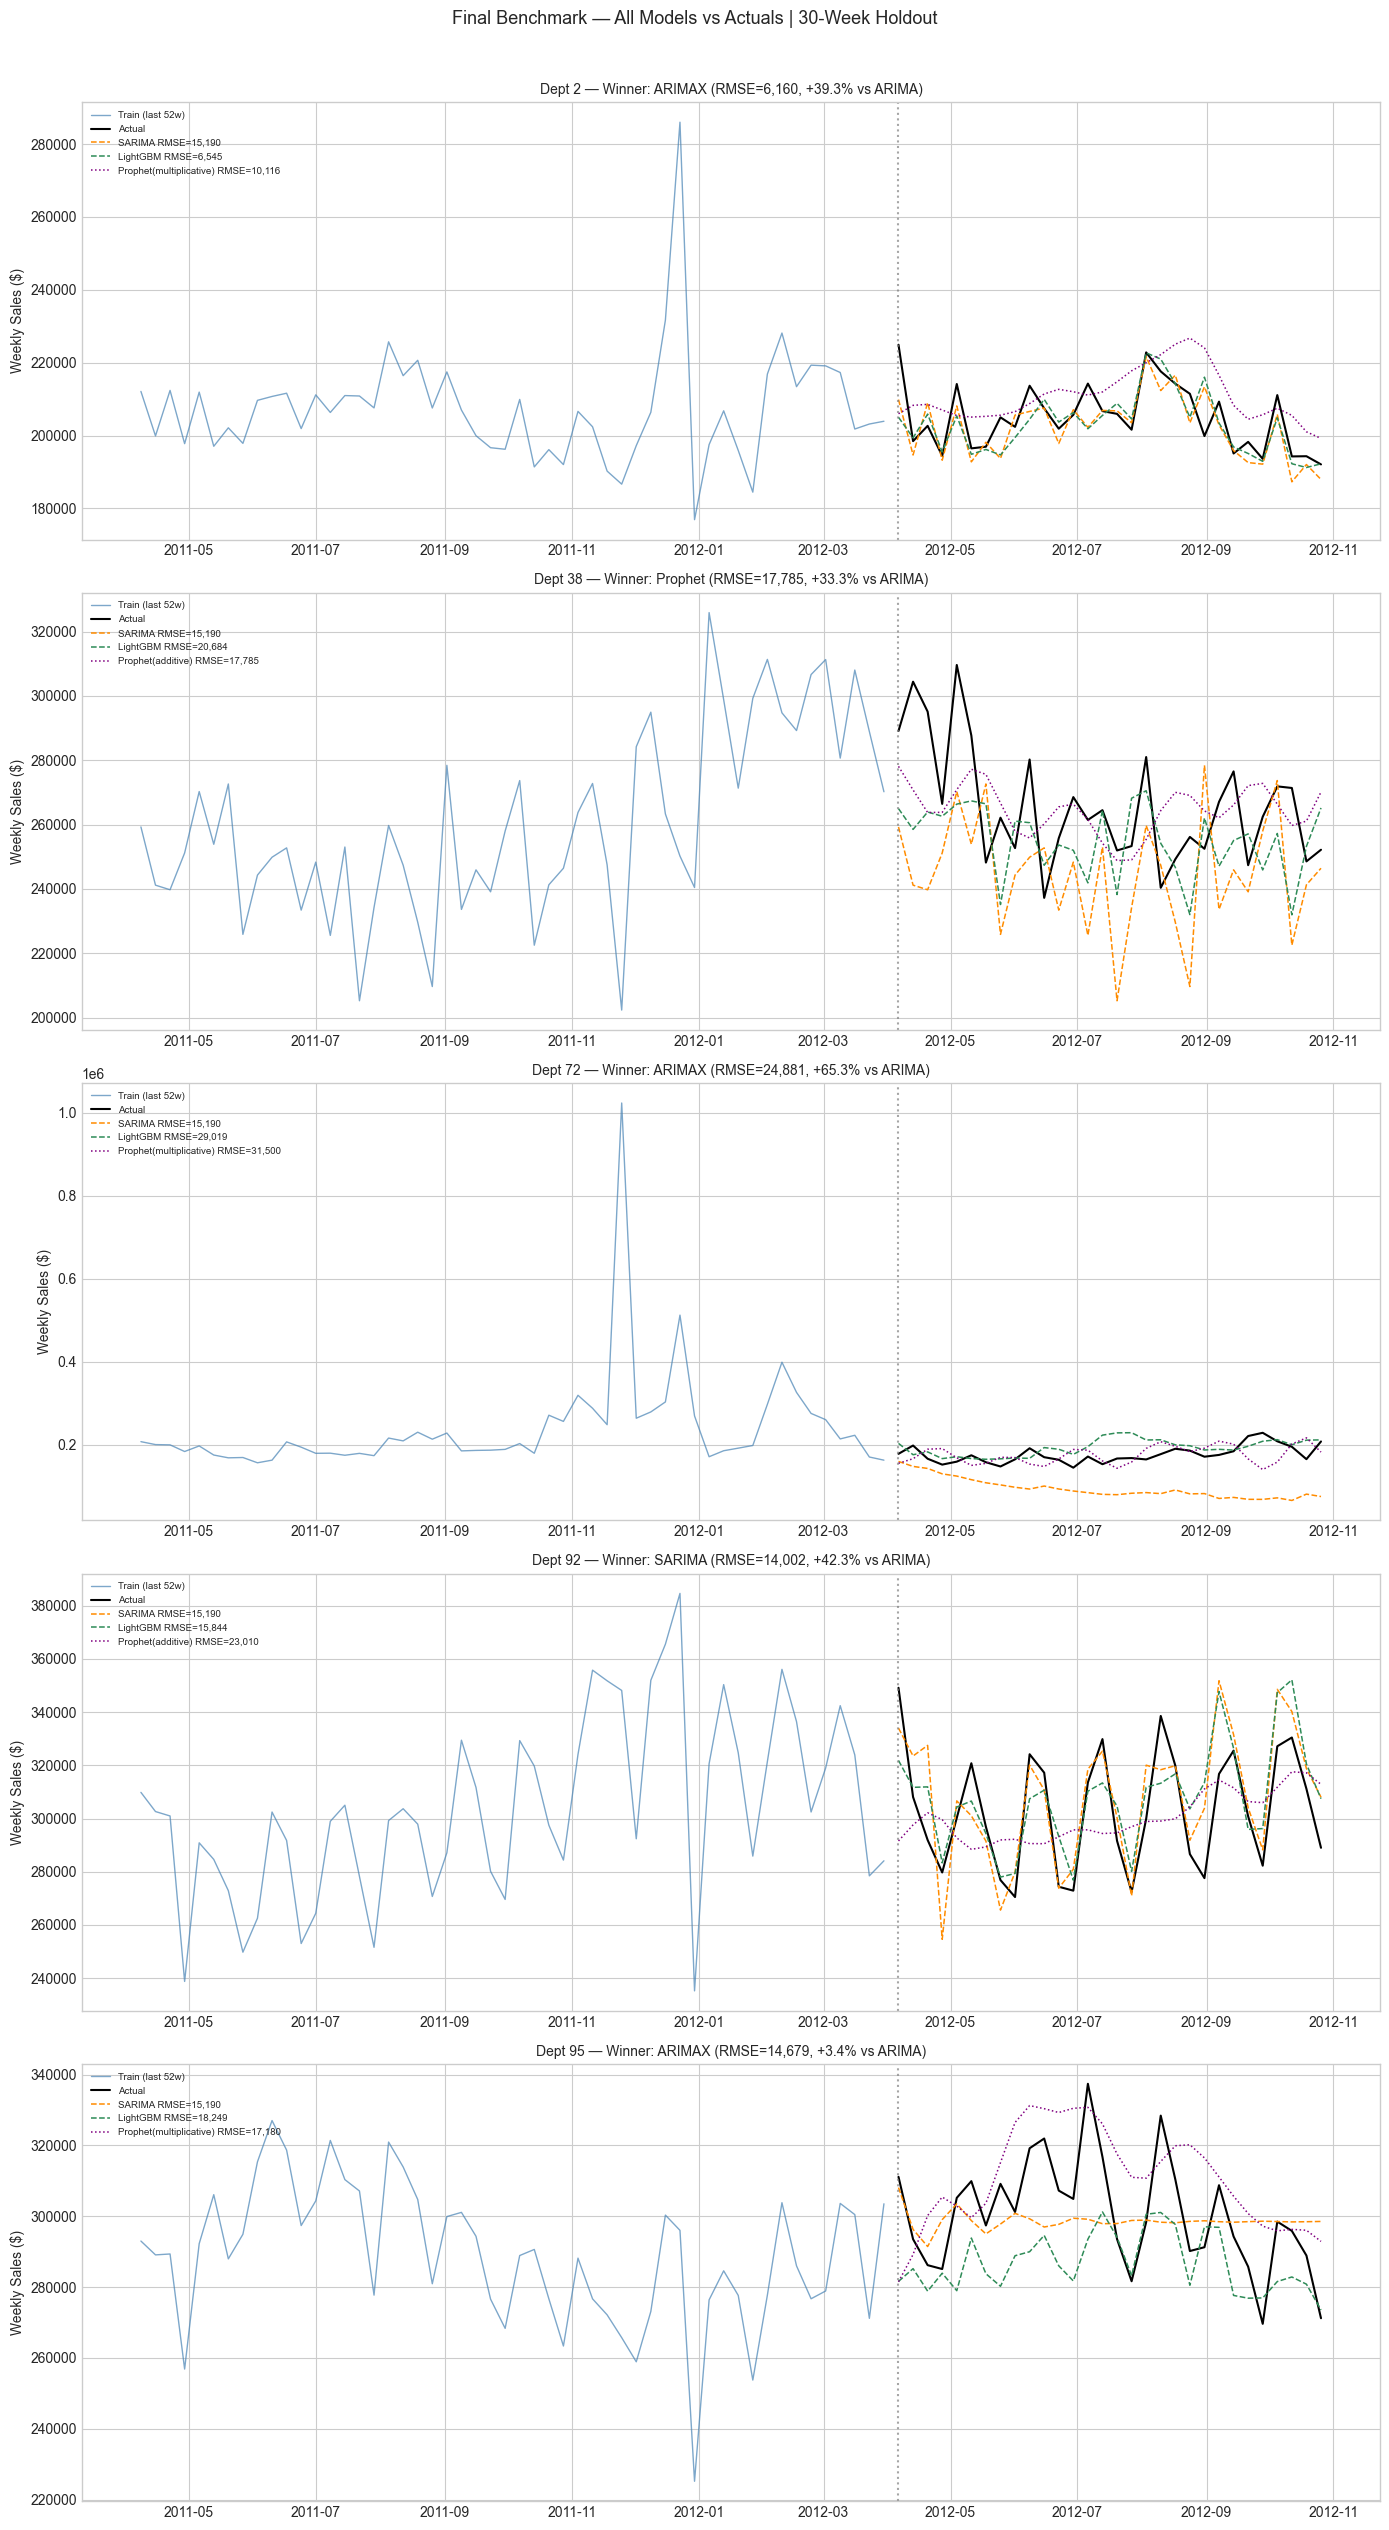

Saved → outputs/16_final_forecast_comparison.png


In [12]:
fig, axes = plt.subplots(len(DEPTS), 1, figsize=(14, 5*len(DEPTS)))

for i, dept in enumerate(DEPTS):
    series      = build_series(dept)
    train, test = split_series(series)
    context     = train.iloc[-52:]
    test_index  = test.index

    # SARIMA predictions
    from statsmodels.tsa.statespace.sarimax import SARIMAX as SM
    day2_row = arima_df[arima_df['dept']==dept].iloc[0]
    import ast
    try:
        sarima_order = ast.literal_eval(str(day2_row['SARIMA Order']).split('x')[0])
        seasonal_str = str(day2_row['SARIMA Order']).split('x')[1] if 'x' in str(day2_row['SARIMA Order']) else '(0,0,0,0)'
        seasonal_order = ast.literal_eval(seasonal_str)
    except:
        sarima_order   = (1,1,0)
        seasonal_order = (0,1,0,52)

    sarima_fit  = SM(train, order=sarima_order,
                     seasonal_order=seasonal_order,
                     enforce_stationarity=False,
                     enforce_invertibility=False).fit(disp=False)
    sarima_preds = np.maximum(sarima_fit.forecast(steps=HOLDOUT), 0)

    # LightGBM predictions
    lgbm_preds = lgbm_results[dept]['predictions']

    axes[i].plot(context.index, context.values,
                 color='steelblue', linewidth=1.0,
                 label='Train (last 52w)', alpha=0.7)
    axes[i].plot(test_index, test.values,
                 color='black', linewidth=1.5, label='Actual')
    axes[i].plot(test_index, sarima_preds,
                 color='darkorange', linewidth=1.1, linestyle='--',
                 label=f'SARIMA RMSE={sarima_rmse:,.0f}')
    axes[i].plot(test_index, lgbm_preds,
                 color='seagreen', linewidth=1.1, linestyle='--',
                 label=f'LightGBM RMSE={lgbm_results[dept]["RMSE"]:,.0f}')

    # Add Prophet 

    prophet_preds = prophet_results[dept]['predictions']
    axes[i].plot(test_index, prophet_preds,
                    color='purple', linewidth=1.1, linestyle=':',
                    label=f'Prophet({prophet_results[dept]["mode"]}) RMSE={prophet_results[dept]["RMSE"]:,.0f}')

    axes[i].axvline(test_index[0], color='gray', linestyle=':', alpha=0.7)

    row = benchmark_df[benchmark_df['Dept']==dept].iloc[0]
    axes[i].set_title(
        f'Dept {dept} — Winner: {row["Overall Winner"]} '
        f'(RMSE={row["Best RMSE"]:,.0f}, {row["vs ARIMA %"]:+.1f}% vs ARIMA)',
        fontsize=10)
    axes[i].set_ylabel('Weekly Sales ($)')
    axes[i].legend(fontsize=7, loc='upper left')

plt.suptitle('Final Benchmark — All Models vs Actuals | 30-Week Holdout',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/16_final_forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/16_final_forecast_comparison.png')

---
## 9. LightGBM Deep Dive — Key Departments

> Focus on Dept 38 (structural break) and Dept 95 (unexplained variance).
> Did LightGBM overcome what statistical models couldn't?

In [13]:
print('LightGBM vs SARIMA — Focus Departments')
print('=' * 60)
print()

focus_depts = [38, 72, 95]
for dept in focus_depts:
    sarima_rmse_val = float(arima_df[arima_df['dept']==dept]['SARIMA RMSE'].iloc[0])
    lgbm_rmse_val   = lgbm_results[dept]['RMSE']
    improvement     = (sarima_rmse_val - lgbm_rmse_val) / sarima_rmse_val * 100
    top3_features   = feature_importance_dfs[dept].head(3)['feature'].tolist()

    print(f'Dept {dept}:')
    print(f'  SARIMA RMSE    : {sarima_rmse_val:>10,.2f}')
    print(f'  LightGBM RMSE  : {lgbm_rmse_val:>10,.2f}  ({improvement:+.1f}% vs SARIMA)')
    print(f'  Top 3 features : {top3_features}')
    print()

print()
print('Dept 38 analysis:')
print('  Structural break ~Nov 2011 made SARIMA unstable (Ljung-Box p=0.000)')
print('  LightGBM has no stationarity assumption — lag features adapt naturally')
print('  lag_52 feature implicitly captures year-over-year pattern post-break')
print()
print('Dept 95 analysis:')
print('  SARIMA MAPE 3.86% — good but both models missed late holdout surge')
print('  LightGBM lag_1 and rolling features may capture short-term momentum')
print('  Check if MAPE improved on late holdout weeks specifically')

# Late holdout check for Dept 95
data_95    = build_lgbm_features(95)
_, test_95 = split_df(data_95)
series_95  = build_series(95)
_, test_s95= split_series(series_95)

lgbm_preds_95 = lgbm_results[95]['predictions']
actual_95     = test_s95.values

# Split holdout into early (weeks 1-15) and late (weeks 16-30)
early_rmse = np.sqrt(mean_squared_error(actual_95[:15], lgbm_preds_95[:15]))
late_rmse  = np.sqrt(mean_squared_error(actual_95[15:], lgbm_preds_95[15:]))
print()
print(f'Dept 95 LightGBM holdout split:')
print(f'  Weeks  1-15 RMSE: {early_rmse:>10,.2f}')
print(f'  Weeks 16-30 RMSE: {late_rmse:>10,.2f}')
print(f'  (Higher late RMSE = model struggles with the late surge)')

LightGBM vs SARIMA — Focus Departments

Dept 38:
  SARIMA RMSE    :  23,031.93
  LightGBM RMSE  :  20,684.43  (+10.2% vs SARIMA)
  Top 3 features : ['lag_52', 'fuel_price_lag1', 'lag_4']

Dept 72:
  SARIMA RMSE    :  27,768.65
  LightGBM RMSE  :  29,019.08  (-4.5% vs SARIMA)
  Top 3 features : ['lag_52', 'fuel_price_lag1', 'week_of_year']

Dept 95:
  SARIMA RMSE    :  15,189.77
  LightGBM RMSE  :  18,249.37  (-20.1% vs SARIMA)
  Top 3 features : ['lag_52', 'rolling_std_8', 'lag_12']


Dept 38 analysis:
  Structural break ~Nov 2011 made SARIMA unstable (Ljung-Box p=0.000)
  LightGBM has no stationarity assumption — lag features adapt naturally
  lag_52 feature implicitly captures year-over-year pattern post-break

Dept 95 analysis:
  SARIMA MAPE 3.86% — good but both models missed late holdout surge
  LightGBM lag_1 and rolling features may capture short-term momentum
  Check if MAPE improved on late holdout weeks specifically

Dept 95 LightGBM holdout split:
  Weeks  1-15 RMSE:  22,904

---
## 10. LightGBM Residual Analysis

> LightGBM doesn't have a Ljung-Box equivalent — it's not a statistical model.
> Instead: plot residuals, check for systematic patterns, compute error by time period.

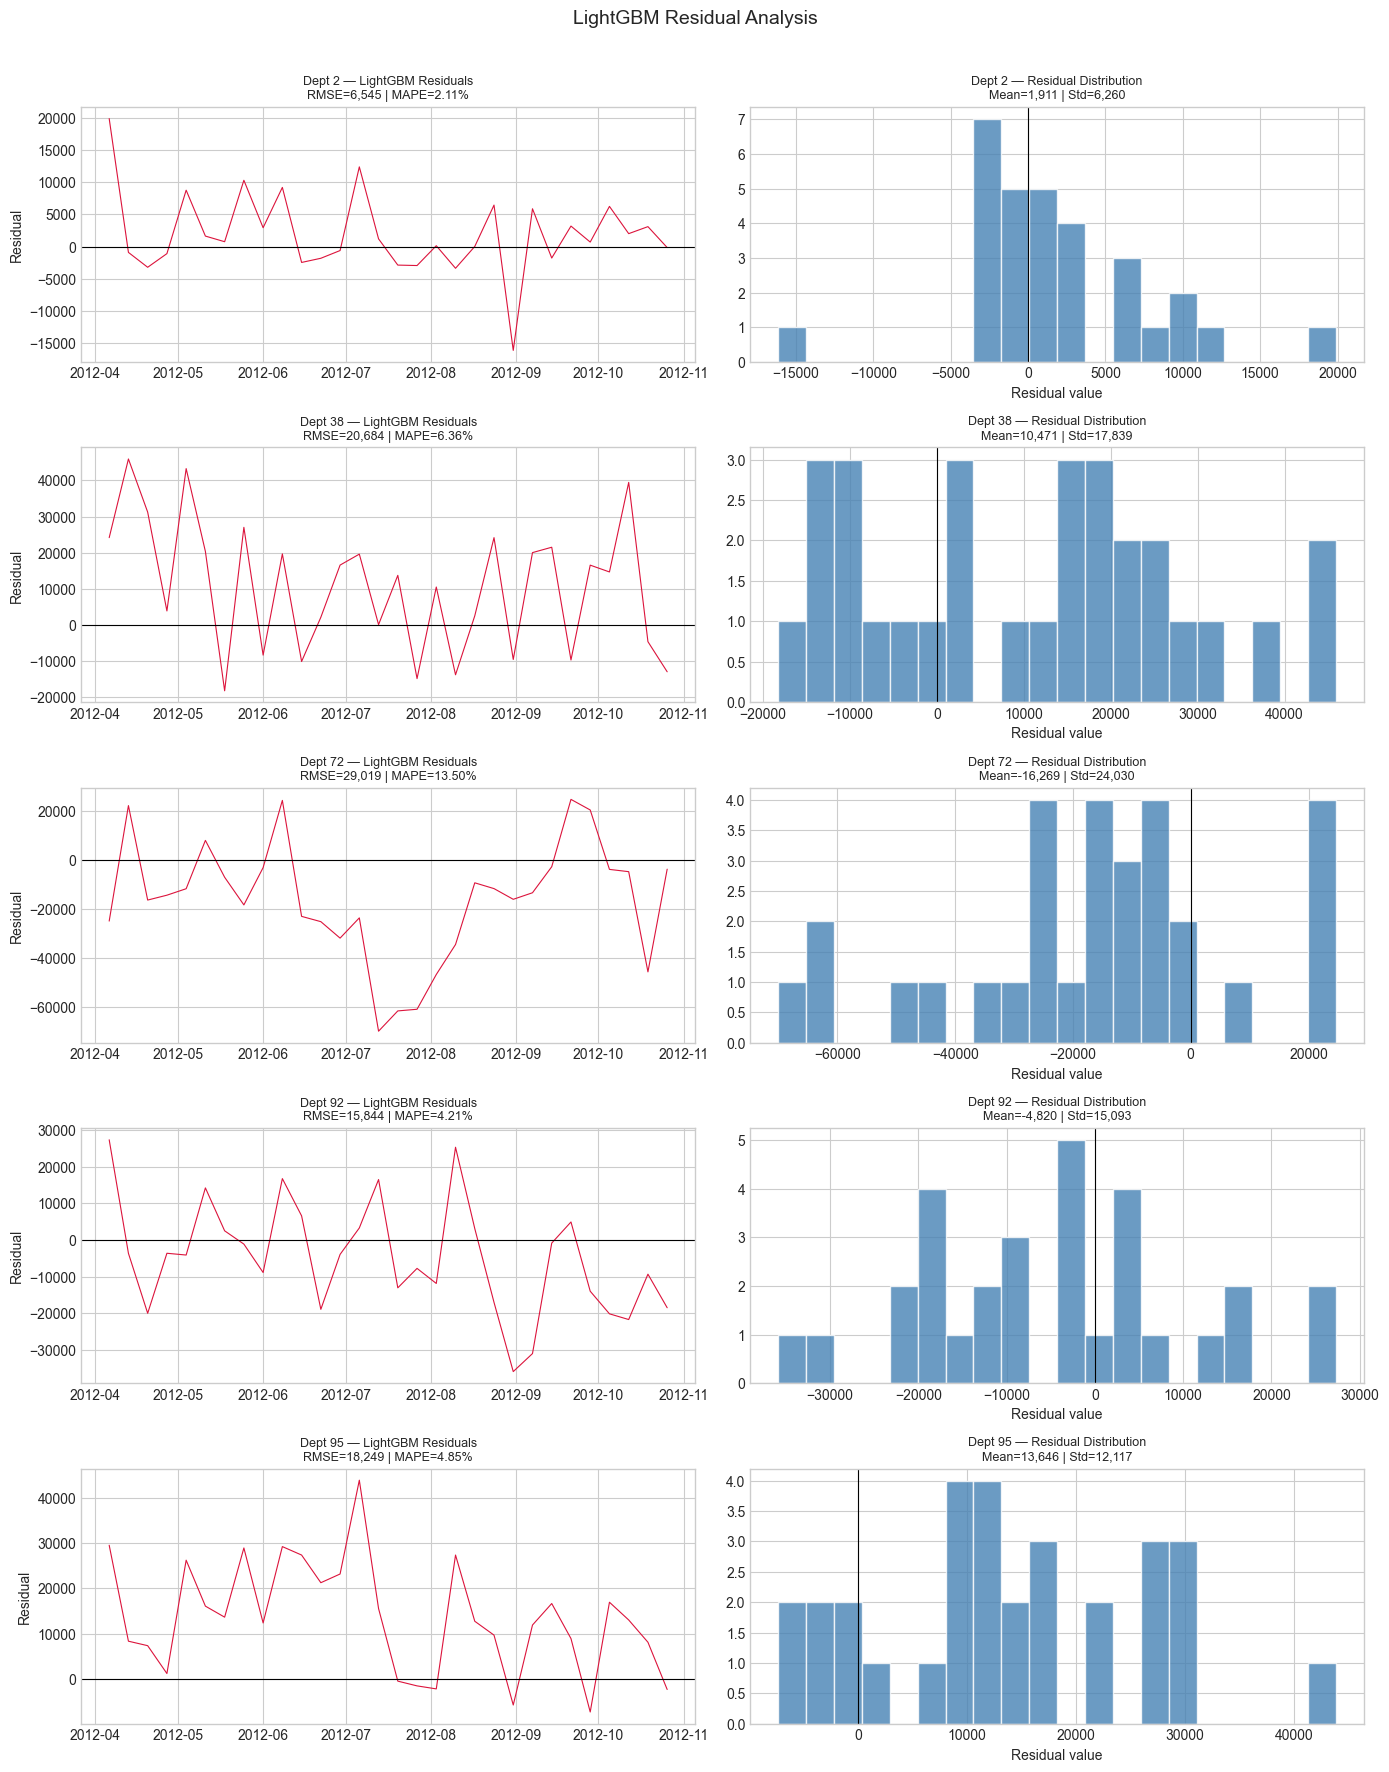

Saved → outputs/17_lgbm_residuals.png


In [14]:
fig, axes = plt.subplots(len(DEPTS), 2, figsize=(14, 3.5*len(DEPTS)))

for i, dept in enumerate(DEPTS):
    series      = build_series(dept)
    _, test     = split_series(series)

    preds     = lgbm_results[dept]['predictions']
    residuals = test.values - preds

    # Residual plot
    axes[i][0].plot(test.index, residuals,
                    color='crimson', linewidth=0.8)
    axes[i][0].axhline(0, color='black', linewidth=0.8)
    axes[i][0].set_title(f'Dept {dept} — LightGBM Residuals\n'
                          f'RMSE={lgbm_results[dept]["RMSE"]:,.0f} | '
                          f'MAPE={lgbm_results[dept]["MAPE"]:.2f}%', fontsize=9)
    axes[i][0].set_ylabel('Residual')

    # Histogram
    axes[i][1].hist(residuals, bins=20, color='steelblue',
                    alpha=0.8, edgecolor='white')
    axes[i][1].axvline(0, color='black', linewidth=0.8)
    axes[i][1].set_title(f'Dept {dept} — Residual Distribution\n'
                          f'Mean={residuals.mean():,.0f} | Std={residuals.std():,.0f}',
                          fontsize=9)
    axes[i][1].set_xlabel('Residual value')

plt.suptitle('LightGBM Residual Analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('outputs/17_lgbm_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/17_lgbm_residuals.png')

---
## 11. Day 4 Final Summary

In [15]:
print('=' * 70)
print('DAY 4 COMPLETE — Full Project Benchmark')
print('=' * 70)
print()

print('─── Final Winner per Department ───')
for _, row in benchmark_df.iterrows():
    dept      = row['Dept']
    winner    = row['Overall Winner']
    best_rmse = row['Best RMSE']
    vs_arima  = row['vs ARIMA %']
    lgbm_imp  = lgbm_results[dept]['improvement_%']
    print(f"  Dept {dept:>2}: {winner:10s} | "
          f"Best RMSE={best_rmse:>10,.2f} | "
          f"{vs_arima:>+.1f}% vs ARIMA | "
          f"LightGBM improvement={lgbm_imp:>+.1f}%")

print()
print('─── Model Win Count ───')
for model in ['SARIMA','ARIMAX','Prophet','LightGBM','SARIMA refit']:
    wins = (benchmark_df['Overall Winner'] == model).sum()
    if wins > 0:
        print(f'  {model:12s}: {wins}/5 departments')

print()
print('─── Key Findings ───')
print('  Day 1: Strong annual seasonality (0.82-0.97) across all depts')
print('  Day 2: SARIMA beat ARIMA on 4/5 depts — Dept 72 +61% improvement')
print('  Day 3: ARIMAX genuine wins on 2/5 — aggregation fallacy avoided')
print('  Day 4: LightGBM lag features — check if structural break overcome')
print()
print('─── Resume Bullet Numbers ───')
best_overall = benchmark_df['vs ARIMA %'].max()
print(f'  Best single improvement vs ARIMA: +{best_overall:.1f}%')
print(f'  SARIMA vs ARIMA avg improvement: see day2_baseline_results.csv')
print(f'  Dept 72 ARIMA→best model: '
      f'{(float(arima_df[arima_df["dept"]==72]["ARIMA RMSE"].iloc[0]) - benchmark_df[benchmark_df["Dept"]==72]["Best RMSE"].iloc[0]) / float(arima_df[arima_df["dept"]==72]["ARIMA RMSE"].iloc[0])*100:.1f}%')

print()
print('─── Outputs ───')
for o in ['15_lgbm_feature_importance.png',
          '16_final_forecast_comparison.png',
          '17_lgbm_residuals.png',
          'day4_final_benchmark.csv']:
    print(f'  outputs/{o}')

benchmark_df.to_csv('outputs/day4_final_benchmark.csv', index=False)
print()
print('Project complete. Next: Day 5 README + resume bullet finalisation.')

DAY 4 COMPLETE — Full Project Benchmark

─── Final Winner per Department ───
  Dept  2: ARIMAX     | Best RMSE=  6,160.45 | +39.3% vs ARIMA | LightGBM improvement=-6.2%
  Dept 38: Prophet    | Best RMSE= 17,784.92 | +33.3% vs ARIMA | LightGBM improvement=+10.2%
  Dept 72: ARIMAX     | Best RMSE= 24,880.86 | +65.3% vs ARIMA | LightGBM improvement=-16.6%
  Dept 92: SARIMA     | Best RMSE= 14,001.91 | +42.3% vs ARIMA | LightGBM improvement=-13.2%
  Dept 95: ARIMAX     | Best RMSE= 14,679.49 | +3.4% vs ARIMA | LightGBM improvement=-24.3%

─── Model Win Count ───
  SARIMA      : 1/5 departments
  ARIMAX      : 3/5 departments
  Prophet     : 1/5 departments

─── Key Findings ───
  Day 1: Strong annual seasonality (0.82-0.97) across all depts
  Day 2: SARIMA beat ARIMA on 4/5 depts — Dept 72 +61% improvement
  Day 3: ARIMAX genuine wins on 2/5 — aggregation fallacy avoided
  Day 4: LightGBM lag features — check if structural break overcome

─── Resume Bullet Numbers ───
  Best single improve